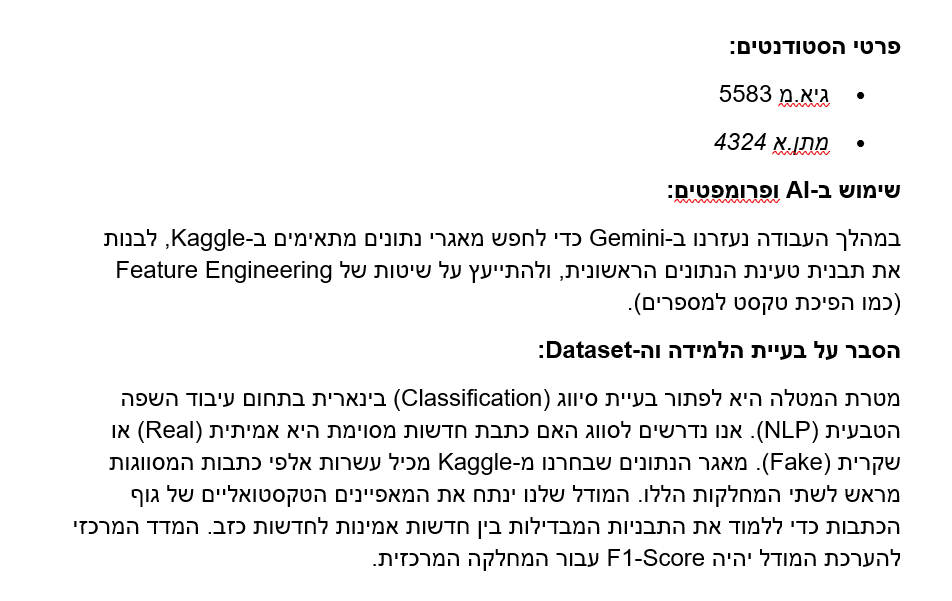

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

true_df = pd.read_csv('True.csv')
fake_df = pd.read_csv('Fake.csv')

fake_df['label'] = 1
true_df['label'] = 0

df = pd.concat([fake_df, true_df], ignore_index=True)

df = df[['text', 'label']]

X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train Set - First 5 rows (X_train):")
print(X_train.head())
print("\nTrain Set Labels - First 5 rows (y_train):")
print(y_train.head())

print("\nTest Set - First 5 rows (X_test):")
print(X_test.head())
print("\nTest Set Labels - First 5 rows (y_test):")
print(y_test.head())

Train Set - First 5 rows (X_train):
36335    ATHENS (Reuters) - Turkish President Tayyip Er...
12384    Ted Cruz would be fair, honest and most of all...
24419    WASHINGTON (Reuters) - White House Chief of St...
24740    DUBAI (Reuters) - Saudi Arabia welcomed the ne...
27039    SIGONELLA, Italy (Reuters) - U.S. President Do...
Name: text, dtype: object

Train Set Labels - First 5 rows (y_train):
36335    0
12384    1
24419    0
24740    0
27039    0
Name: label, dtype: int64

Test Set - First 5 rows (X_test):
22216    21st Century Wire says Ben Stein, reputable pr...
27917    WASHINGTON (Reuters) - U.S. President Donald T...
25007    (Reuters) - Puerto Rico Governor Ricardo Rosse...
1377     On Monday, Donald Trump once again embarrassed...
32476    GLASGOW, Scotland (Reuters) - Most U.S. presid...
Name: text, dtype: object

Test Set Labels - First 5 rows (y_test):
22216    1
27917    0
25007    0
1377     1
32476    0
Name: label, dtype: int64


חלק 2

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd


tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_features = tfidf.fit_transform(X_train)
X_test_features = tfidf.transform(X_test)

feature_names = tfidf.get_feature_names_out()

def display_examples(data_source, feature_matrix, set_name):
    print(f"\n--- Feature Engineering: {set_name} Set (2 Examples) ---")
    example_texts = data_source.head(2)
    example_vectors = feature_matrix[:2]
    df_examples = pd.DataFrame(example_vectors.toarray(), columns=feature_names)

    for i, (original_index, text) in enumerate(example_texts.items()):
        print(f"\n--- {set_name} Example {i+1} ---")
        print("Original Text (First 100 characters):")
        print(text[:100] + "...")
        print("\nTop 5 features with the highest weight:")
        doc_features = df_examples.iloc[i]
        top_features = doc_features[doc_features > 0].sort_values(ascending=False).head(5)
        print(top_features)

display_examples(X_train, X_train_features, "Train")
display_examples(X_test, X_test_features, "Test")


--- Feature Engineering: Train Set (2 Examples) ---

--- Train Example 1 ---
Original Text (First 100 characters):
ATHENS (Reuters) - Turkish President Tayyip Erdogan said on Thursday that U.S. President Donald Trum...

Top 5 features with the highest weight:
erdogan      0.489078
talks        0.330480
tayyip       0.246552
jerusalem    0.236585
turkish      0.222311
Name: 0, dtype: float64

--- Train Example 2 ---
Original Text (First 100 characters):
Ted Cruz would be fair, honest and most of all, he would follow the law. He would hands down be one ...

Top 5 features with the highest weight:
cruz         0.688775
trump        0.211947
ted          0.204352
discussed    0.139666
attorney     0.115475
Name: 1, dtype: float64

--- Feature Engineering: Test Set (2 Examples) ---

--- Test Example 1 ---
Original Text (First 100 characters):
21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Holl...

Top 5 features with the highest weight:
stei

חלק 3

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

class KNNModel:
    def __init__(self, n_neighbors=5, weights='uniform', metric='minkowski'):
        self.model = KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            metric=metric
        )

    def train(self, X, y):
        print(f"Starting training KNN with k={self.model.n_neighbors}...")
        self.model.fit(X, y)
        print("Training completed.")

    def predict(self, X):
        return self.model.predict(X)

my_knn_model = KNNModel(n_neighbors=7, weights='distance')

חלק 4

In [ ]:
my_knn_model.train(X_train_features, y_train)

print("\n--- Training Flow: Feature Engineering Process (3 Examples) ---")

demo_samples = X_train.head(3)
demo_vectors = X_train_features[:3]
feature_names = tfidf.get_feature_names_out()

for i, (idx, text) in enumerate(demo_samples.items()):
    print(f"\n--- Training Example {i+1} ---")
    print("Step 1: Raw Text Input (First 150 characters):")
    print(text[:150] + "...")

    print("\nStep 2: TF-IDF Feature Transformation (Top 5 keywords):")
    doc_vector = pd.Series(demo_vectors[i].toarray()[0], index=feature_names)
    top_keywords = doc_vector.sort_values(ascending=False).head(5)
    print(top_keywords)

    print("\nStep 3: Ready for Model Training")

Starting training KNN with k=7...
Training completed.

--- Training Flow: Feature Engineering Process (3 Examples) ---

--- Training Example 1 ---
Step 1: Raw Text Input (First 150 characters):
ATHENS (Reuters) - Turkish President Tayyip Erdogan said on Thursday that U.S. President Donald Trump s  unfortunate  decision to recognize Jerusalem ...

Step 2: TF-IDF Feature Transformation (Top 5 keywords):
erdogan      0.489078
talks        0.330480
tayyip       0.246552
jerusalem    0.236585
turkish      0.222311
dtype: float64

Step 3: Ready for Model Training

--- Training Example 2 ---
Step 1: Raw Text Input (First 150 characters):
Ted Cruz would be fair, honest and most of all, he would follow the law. He would hands down be one of the best choices for this position President-el...

Step 2: TF-IDF Feature Transformation (Top 5 keywords):
cruz         0.688775
trump        0.211947
ted          0.204352
discussed    0.139666
attorney     0.115475
dtype: float64

Step 3: Ready for Model 

חלק 5

In [ ]:
from sklearn.metrics import f1_score

y_pred = my_knn_model.predict(X_test_features)

print("--- Test Set: Feature Engineering Process (3 Examples) ---")
test_samples = X_test.head(3)
test_vectors = X_test_features[:3]

for i, (idx, text) in enumerate(test_samples.items()):
    print(f"\n--- Test Example {i+1} ---")
    print("Step 1: Raw Text:")
    print(text[:150] + "...")
    print("\nStep 2: TF-IDF Transformation (Top 3 Keywords):")
    doc_vector = pd.Series(test_vectors[i].toarray()[0], index=feature_names)
    print(doc_vector.sort_values(ascending=False).head(3))

print("\n--- First 5 Prediction Results ---")
print("Predicted labels: ", y_pred[:5])
print("Actual labels:    ", y_test[:5].values)

f1 = f1_score(y_test, y_pred, pos_label=1)
print(f"\nModel Quality (F1-Score for Fake News): {f1:.4f}")

--- Test Set: Feature Engineering Process (3 Examples) ---

--- Test Example 1 ---
Step 1: Raw Text:
21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as...

Step 2: TF-IDF Transformation (Top 3 Keywords):
stein        0.418260
halt         0.232023
executive    0.231194
dtype: float64

--- Test Example 2 ---
Step 1: Raw Text:
WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversin...

Step 2: TF-IDF Transformation (Top 3 Keywords):
bannon      0.595034
mcmaster    0.238081
security    0.198376
dtype: float64

--- Test Example 3 ---
Step 1: Raw Text:
(Reuters) - Puerto Rico Governor Ricardo Rossello said on Wednesday he expected the federal government to waive the Jones Act, which would lift restri...

Step 2: TF-IDF Transformation (Top 3 Keywords):
fuel      0.371170
ships     0.351088
island   

חלק 6 א

In [18]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np

X_train_sample = X_train.sample(frac=0.15, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

param_grid = {
    'max_features': [2000, 5000],
    'n_neighbors': [5, 11]
}

results_list = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Starting faster Grid Search on {len(X_train_sample)} samples...")

for max_feat in param_grid['max_features']:
    for k in param_grid['n_neighbors']:
        fold_f1_scores = []

        for train_index, val_index in kf.split(X_train_sample):
            X_fold_train, X_fold_val = X_train_sample.iloc[train_index], X_train_sample.iloc[val_index]
            y_fold_train, y_fold_val = y_train_sample.iloc[train_index], y_train_sample.iloc[val_index]

            fold_tfidf = TfidfVectorizer(stop_words='english', max_features=max_feat)
            X_fold_train_features = fold_tfidf.fit_transform(X_fold_train)
            X_fold_val_features = fold_tfidf.transform(X_fold_val)

            fold_model = KNeighborsClassifier(n_neighbors=k)
            fold_model.fit(X_fold_train_features, y_fold_train)

            y_fold_pred = fold_model.predict(X_fold_val_features)
            fold_f1 = f1_score(y_fold_val, y_fold_pred, pos_label=1)
            fold_f1_scores.append(fold_f1)

        mean_f1 = np.mean(fold_f1_scores)
        results_list.append({
            'max_features': max_feat,
            'n_neighbors': k,
            'mean_f1_score': mean_f1
        })
        print(f"Done: max_features={max_feat}, k={k} | Mean F1: {mean_f1:.4f}")

results_df = pd.DataFrame(results_list)
print("\n--- Final Grid Search Results ---")
print(results_df)

best_run = results_df.loc[results_df['mean_f1_score'].idxmax()]
print(f"\nBest Permutation: max_features={int(best_run['max_features'])}, k={int(best_run['n_neighbors'])}")

Starting faster Grid Search on 5388 samples...
Done: max_features=2000, k=5 | Mean F1: 0.7244
Done: max_features=2000, k=11 | Mean F1: 0.7092
Done: max_features=5000, k=5 | Mean F1: 0.7124
Done: max_features=5000, k=11 | Mean F1: 0.6962

--- Final Grid Search Results ---
   max_features  n_neighbors  mean_f1_score
0          2000            5       0.724383
1          2000           11       0.709249
2          5000            5       0.712415
3          5000           11       0.696178

Best Permutation: max_features=2000, k=5


In [19]:

BEST_MAX_FEATURES = 2000
BEST_K = 5

print(f"--- Final Training with Best Params: max_features={BEST_MAX_FEATURES}, k={BEST_K} ---")

final_tfidf = TfidfVectorizer(stop_words='english', max_features=BEST_MAX_FEATURES)
X_train_final = final_tfidf.fit_transform(X_train)
X_test_final = final_tfidf.transform(X_test)

final_model = KNeighborsClassifier(n_neighbors=BEST_K)
final_model.fit(X_train_final, y_train)

y_pred_final = final_model.predict(X_test_final)
final_f1 = f1_score(y_test, y_pred_final, pos_label=1)

print("\n--- Final Model Evaluation ---")
print(f"Final F1-Score on Test Set: {final_f1:.4f}")

print("\nFirst 5 Predictions:")
print("Predicted: ", y_pred_final[:5])
print("Actual:    ", y_test[:5].values)

--- Final Training with Best Params: max_features=2000, k=5 ---

--- Final Model Evaluation ---
Final F1-Score on Test Set: 0.7924

First 5 Predictions:
Predicted:  [1 0 0 1 1]
Actual:     [1 0 0 1 0]


חלק 6 ג

In [21]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np

param_grid_6c = {
    'max_features': [2000, 5000],
    'n_neighbors': [5, 11],
    'weights': ['uniform', 'distance']
}

results_list_6c = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Starting Hyperparameter Tuning (Part 6.c) on {len(X_train_sample)} samples...")
print("Testing permutations of max_features, n_neighbors, and weights...\n")

for max_feat in param_grid_6c['max_features']:
    for k in param_grid_6c['n_neighbors']:
        for w in param_grid_6c['weights']:
            fold_f1_scores = []

            for train_index, val_index in kf.split(X_train_sample):
                X_fold_train, X_fold_val = X_train_sample.iloc[train_index], X_train_sample.iloc[val_index]
                y_fold_train, y_fold_val = y_train_sample.iloc[train_index], y_train_sample.iloc[val_index]

                fold_tfidf = TfidfVectorizer(stop_words='english', max_features=max_feat)
                X_fold_train_features = fold_tfidf.fit_transform(X_fold_train)
                X_fold_val_features = fold_tfidf.transform(X_fold_val)

                fold_model = KNeighborsClassifier(n_neighbors=k, weights=w)
                fold_model.fit(X_fold_train_features, y_fold_train)


                y_fold_pred = fold_model.predict(X_fold_val_features)
                fold_f1 = f1_score(y_fold_val, y_fold_pred, pos_label=1)
                fold_f1_scores.append(fold_f1)

            mean_f1 = np.mean(fold_f1_scores)
            results_list_6c.append({
                'max_features': max_feat,
                'n_neighbors': k,
                'weights': w,
                'mean_f1_score': mean_f1
            })
            print(f"Done: max_features={max_feat}, k={k}, weights={w} | Mean F1: {mean_f1:.4f}")

results_df_6c = pd.DataFrame(results_list_6c)
print("\n--- Final Results DataFrame (Part 6.c) ---")
print(results_df_6c.sort_values(by='mean_f1_score', ascending=False).to_string(index=False))

best_run_6c = results_df_6c.loc[results_df_6c['mean_f1_score'].idxmax()]
print(f"\nBest Permutation: max_features={int(best_run_6c['max_features'])}, k={int(best_run_6c['n_neighbors'])}, weights={best_run_6c['weights']}")

Starting Hyperparameter Tuning (Part 6.c) on 5388 samples...
Testing permutations of max_features, n_neighbors, and weights...

Done: max_features=2000, k=5, weights=uniform | Mean F1: 0.7244
Done: max_features=2000, k=5, weights=distance | Mean F1: 0.7253
Done: max_features=2000, k=11, weights=uniform | Mean F1: 0.7092
Done: max_features=2000, k=11, weights=distance | Mean F1: 0.7109
Done: max_features=5000, k=5, weights=uniform | Mean F1: 0.7124
Done: max_features=5000, k=5, weights=distance | Mean F1: 0.7136
Done: max_features=5000, k=11, weights=uniform | Mean F1: 0.6962
Done: max_features=5000, k=11, weights=distance | Mean F1: 0.6979

--- Final Results DataFrame (Part 6.c) ---
 max_features  n_neighbors  weights  mean_f1_score
         2000            5 distance       0.725348
         2000            5  uniform       0.724383
         5000            5 distance       0.713616
         5000            5  uniform       0.712415
         2000           11 distance       0.710891
  

In [22]:
BEST_MAX_FEATURES = 2000
BEST_K = 5
BEST_WEIGHTS = 'distance'

print(f"--- Final Training with Best Params: max_features={BEST_MAX_FEATURES}, k={BEST_K}, weights={BEST_WEIGHTS} ---")

final_tfidf = TfidfVectorizer(stop_words='english', max_features=BEST_MAX_FEATURES)
X_train_final = final_tfidf.fit_transform(X_train)
X_test_final = final_tfidf.transform(X_test)

final_model = KNeighborsClassifier(n_neighbors=BEST_K, weights=BEST_WEIGHTS)
final_model.fit(X_train_final, y_train)

y_pred_final = final_model.predict(X_test_final)
final_f1 = f1_score(y_test, y_pred_final, pos_label=1)

print("\n--- Final Model Evaluation ---")
print(f"Final F1-Score on Test Set: {final_f1:.4f}")

print("\nFirst 5 Predictions:")
print("Predicted: ", y_pred_final[:5])
print("Actual:    ", y_test[:5].values)

--- Final Training with Best Params: max_features=2000, k=5, weights=distance ---

--- Final Model Evaluation ---
Final F1-Score on Test Set: 0.8026

First 5 Predictions:
Predicted:  [1 0 0 1 1]
Actual:     [1 0 0 1 0]


חלק 6 ו

In [23]:
import pandas as pd

idx_to_explain = 0
test_instance_vector = X_test_final[idx_to_explain]
actual_label = y_test.iloc[idx_to_explain]
predicted_label = y_pred_final[idx_to_explain]

print(f"--- Explainability (XAI) for Test Example {idx_to_explain} ---")
print(f"Model Predicted Label: {predicted_label} | Actual Label: {actual_label}\n")

distances, indices = final_model.kneighbors(test_instance_vector)
feature_names = final_tfidf.get_feature_names_out()

print("--- Why did the KNN model make this decision? ---")
print(f"The model found the {BEST_K} most similar articles in the training set.")
print("Here are those neighbors and their highest-weighted TF-IDF words:\n")

fake_votes = 0
real_votes = 0

for i in range(BEST_K):
    neighbor_idx = indices[0][i]
    distance = distances[0][i]
    neighbor_label = y_train.iloc[neighbor_idx]

    if neighbor_label == 1:
        fake_votes += 1
    else:
        real_votes += 1

    print(f"Neighbor {i+1} | Label: {neighbor_label} | Distance: {distance:.4f}")

    neighbor_vector = X_train_final[neighbor_idx].toarray()[0]
    top_words = pd.Series(neighbor_vector, index=feature_names).sort_values(ascending=False).head(3)

    words_str = ", ".join([f"'{word}' ({weight:.2f})" for word, weight in top_words.items()])
    print(f"Top defining words: {words_str}\n")

print("--- Final Explanation ---")
print(f"Votes breakdown: {fake_votes} for Fake (1), {real_votes} for Real (0).")
print("Conclusion: The model made its classification based on the majority vote of these specific neighbors, because they share similar high-weight keywords from the TF-IDF feature engineering.")

--- Explainability (XAI) for Test Example 0 ---
Model Predicted Label: 1 | Actual Label: 1

--- Why did the KNN model make this decision? ---
The model found the 5 most similar articles in the training set.
Here are those neighbors and their highest-weighted TF-IDF words:

Neighbor 1 | Label: 1 | Distance: 0.0000
Top defining words: 'executive' (0.30), 'note' (0.26), '21st' (0.25)

Neighbor 2 | Label: 1 | Distance: 1.0000
Top defining words: 'wouldn' (0.00), 'worth' (0.00), 'worst' (0.00)

Neighbor 3 | Label: 1 | Distance: 1.0000
Top defining words: 'wouldn' (0.00), 'worth' (0.00), 'worst' (0.00)

Neighbor 4 | Label: 1 | Distance: 1.0000
Top defining words: 'wouldn' (0.00), 'worth' (0.00), 'worst' (0.00)

Neighbor 5 | Label: 1 | Distance: 1.0000
Top defining words: 'wouldn' (0.00), 'worth' (0.00), 'worst' (0.00)

--- Final Explanation ---
Votes breakdown: 5 for Fake (1), 0 for Real (0).
Conclusion: The model made its classification based on the majority vote of these specific neighbors